# The market's "randomness dial" — can low entropy time your trades? 🎲
### When returns get *more orderly*, is a tradable window opening? In plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predictable_%3D_profitable%3F: Busted](https://img.shields.io/badge/Predictable_%3D_profitable%3F-Busted-8b949e?style=flat-square)

Here's a seductive idea borrowed from physics. Imagine the market has a **randomness dial**: most of the time it's spun all the way up — pure noise, unpredictable — but every so often it dips, the tape gets *orderly*, returns fall into a more **predictable** pattern. The pitch: catch those low-randomness moments and you've found a **window** where the market is forecastable, so you should trade.

It sounds rigorous — there's even a real number for it, called **entropy**. But two things quietly go wrong. First, the stock market's dial is **pinned near the top almost always** — daily returns are about as random as a coin. Second, and worse: *predictable* is **not** the same as *profitable*. A pattern can be easy to forecast and still pay you nothing.

> 📓 **Plain-language layer.** Want the entropy formulas, the HAC *t*-stats and the bootstrap? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A note up front.** Every chart is drawn by the code beside it; the real tape is SPY from yfinance, and the synthetic example runs with no network. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from entropy_efficiency import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
# the entropy clock (causal permutation entropy of returns) + low-entropy regime
ENT = st.rolling_entropy(F["ret"], window=60, kind="perm") if HAVE_REAL else None
MASK = st.low_entropy_mask(ENT, q=0.20) if HAVE_REAL else None
print("real SPY cache present:", HAVE_REAL,
      "| low-entropy days:", (0 if MASK is None else int(MASK.sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-04', 'end': '2026-06-18', 'days': 7917, 'years': 31.5, 'ent_mean': 0.98, 'ent_lo': 0.9, 'ent_hi': 1.0, 'n_low': 1513, 'low_frac': 19, 'h1': (1, 1513, 6403, 0.053, 0.049, 0.004, 54, 54, 0.17, 0.882), 'h5': (5, 1513, 6399, 0.277, 0.232, 0.045, 58, 59, 0.44, 0.735), 'h21': (21, 1513, 6383, 1.401, 0.902, 0.499, 67, 66, 2.05, 0.3), 's1': (1, 0.02, 54, 54, 0.63, 0.504), 's5': (5, 0.08, 58, 59, 0.66, 0.566), 's21': (21, 0.089, 65, 66, 0.28, 0.861), 'robust': [(0.1, 720, 0.289, 0.89, 0.65), (0.2, 1513, 0.499, 2.05, 0.3), (0.3, 2330, 0.447, 2.15, 0.294)], 'cost': {'exposure': 19, 'turnover': 11.7, 'gross': 1.55, 'gross_sh': 0.2, 'net': 1.43, 'net_sh': 0.19, 'bh': 10.63, 'bh_sh': 0.56}, 'syn': [(0.0, 570, 89, -0.06, -0.94, 0.682), (0.25, 578, 89, 0.47, 6.3, 0.011)]}


real SPY cache present: True | low-entropy days: 1513


## The answer first

| Question | Answer |
|---|---|
| Is the market ever *really* low-entropy (predictable)? | **Barely.** On a 0-to-1 randomness scale, SPY returns average **0.98** — almost pure noise, every day. The "low-entropy" days are only *relatively* calm. |
| Do low-entropy days have higher returns? | **No real edge.** Next-day and next-week returns are **the same** as any other day; only at a *month* does a faint bump appear — and it doesn't survive an honest test. |
| Could you trade it? | **It loses to doing nothing.** Holding only on low-entropy days earns about **+1.4%/yr** — versus **+10.6%/yr** for just buying and holding. |
| So why does the idea persist? | Because *predictable* **sounds like** *profitable*. They're different things — and our lab-made example proves it. |

> Entropy is a real, interesting gauge of how orderly the tape is. But the market is almost never orderly, and where it is, order doesn't pay.

## 1 · The claim

> *"Measure how random recent returns are. When that randomness **drops** — the tape becomes ordered, the next moves more predictable — a tradable window opens. Trade when entropy is low; stand aside when it's high."*

The word **entropy** comes from physics and information theory: it's a single number for *how disordered* a sequence is. High entropy = looks like a coin-flip; low entropy = there's a repeating, forecastable shape. The idea has real academic cousins (econophysicists use entropy to rank how 'efficient' different markets are). The leap the folklore makes is from *'this stretch is more forecastable'* to *'so you can make money on it.'* We'll test that leap directly.

## 2 · So what?

If a falling randomness dial really marked profitable windows, it would be gold: a **regime detector** telling you exactly when the market is forecastable enough to bet on, and when to step aside into cash. That's the dream every 'market timing' system sells. But there's a trap hiding in the word *predictable*. A perfectly predictable pattern — say, *up, up, down, down, repeat* — is trivial to forecast and yet, over a full cycle, goes **nowhere**. Predictability of **shape** is not the same as a positive **expected return**. The whole study is about keeping those two ideas apart.

## 3 · How would we even know?

We build a **randomness clock** on SPY across **32 years** (1995-01-04 → 2026-06-18): for each day, look back 60 days and compute the **permutation entropy** of the returns — a clean 0-to-1 score for how disordered the recent up/down pattern is (using only the *past*, so no cheating).

1. **Tag the calm days.** Mark the **bottom 20%** lowest-entropy (most 'orderly') days.
2. **Measure the payoff.** What did SPY do over the next **1 / 5 / 21 days** on those days vs. all the rest?
3. **Stress the luck.** Low-entropy days arrive in *clumps*, so we can't treat them as thousands of independent bets — we shuffle the clumps thousands of times to see how often pure chance looks this good. That's the honest test.

## 4 · The teardown — let's actually look

**First: how random is the market, really?** Here's the entropy clock over the whole tape. If the market spent real time being 'orderly', this line would swing low often. Watch how it instead hugs the top — the no-information, coin-flip ceiling.

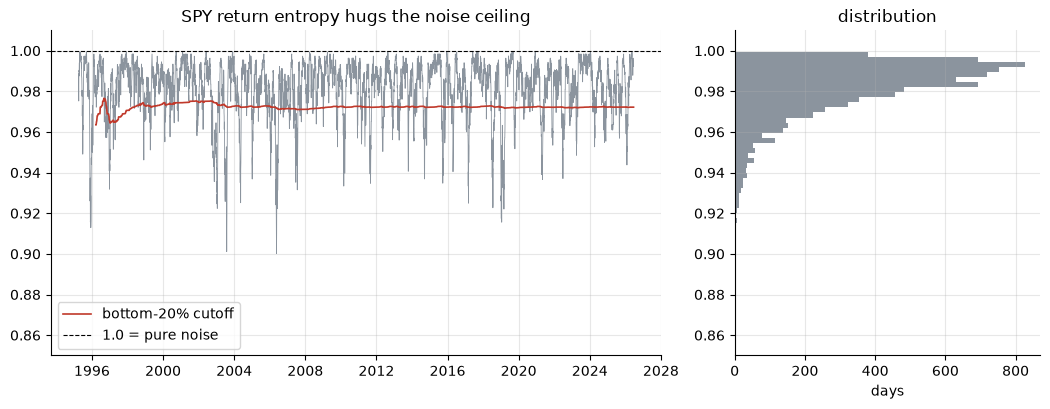

entropy mean 0.981, range [0.900, 0.999] — almost always near 1.0


In [2]:
if HAVE_REAL:
    e = ENT.dropna()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2), gridspec_kw={'width_ratios':[2,1]})
    a1.plot(e.index, e.values, c=GREY, lw=.6)
    thr = ENT.expanding(min_periods=250).quantile(0.20)
    a1.plot(thr.index, thr.values, c=RED, lw=1.2, label='bottom-20% cutoff')
    a1.axhline(1.0, c='k', ls='--', lw=.8, label='1.0 = pure noise')
    a1.set_ylim(0.85, 1.01); a1.set_title('SPY return entropy hugs the noise ceiling'); a1.legend(loc='lower left')
    a2.hist(e.values, bins=40, color=GREY, orientation='horizontal'); a2.set_ylim(0.85, 1.01)
    a2.set_title('distribution'); a2.set_xlabel('days')
    plt.tight_layout(); plt.show()
    print(f'entropy mean {e.mean():.3f}, range [{e.min():.3f}, {e.max():.3f}] — almost always near 1.0')
else:
    print('no cache — frozen: entropy mean', R['ent_mean'], 'range', (R['ent_lo'], R['ent_hi']))

The clock barely leaves the ceiling: mean **0.98**, never below **~0.90**. SPY's daily returns are *almost as disordered as a coin* — there is very little 'order' to harvest in the first place. The 'low-entropy' days are just the *least* random of a uniformly-random crowd.

**Now the real question: do those calm days pay more?** For each horizon, the average forward return on low-entropy days next to high-entropy days — and the win-rate (how often SPY is simply up).

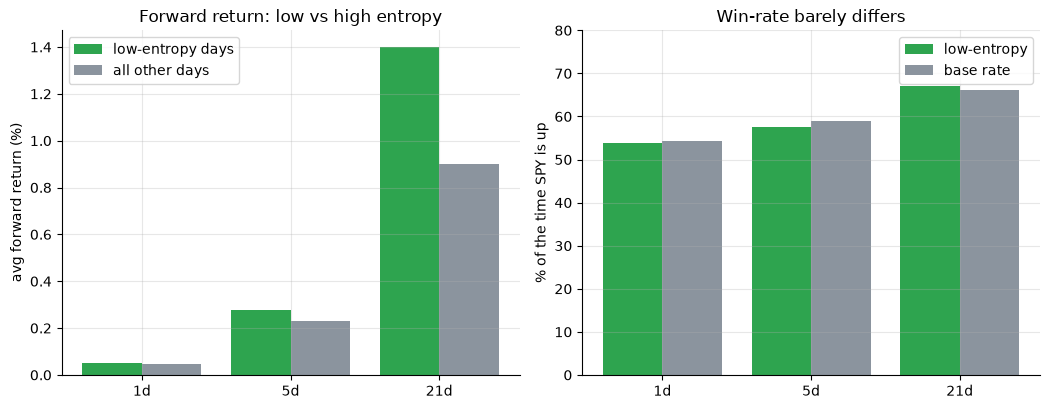

1d/5d/21d low-entropy win-rate: ['54%', '58%', '67%']  vs base: ['54%', '59%', '66%']


In [3]:
hs = [1, 5, 21]
if HAVE_REAL:
    rows = [st.summarize(F, MASK, h) for h in hs]
    lw = [r['low_win']*100 for r in rows]; bw = [r['base_win']*100 for r in rows]
    lm = [r['low_mean']*100 for r in rows]; hm = [r['high_mean']*100 for r in rows]
else:
    lw = [R['h1'][6], R['h5'][6], R['h21'][6]]; bw = [R['h1'][7], R['h5'][7], R['h21'][7]]
    lm = [R['h1'][3], R['h5'][3], R['h21'][3]]; hm = [R['h1'][4], R['h5'][4], R['h21'][4]]
x = np.arange(len(hs))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(x-.2, lm, .4, color=GREEN, label='low-entropy days'); a1.bar(x+.2, hm, .4, color=GREY, label='all other days')
a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs]); a1.set_ylabel('avg forward return (%)')
a1.set_title('Forward return: low vs high entropy'); a1.legend()
a2.bar(x-.2, lw, .4, color=GREEN, label='low-entropy'); a2.bar(x+.2, bw, .4, color=GREY, label='base rate')
a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs]); a2.set_ylim(0,80); a2.set_ylabel('% of the time SPY is up')
a2.set_title('Win-rate barely differs'); a2.legend()
plt.tight_layout(); plt.show()
print('1d/5d/21d low-entropy win-rate:', [f'{v:.0f}%' for v in lw], ' vs base:', [f'{v:.0f}%' for v in bw])

At **1 day** and **5 days** there's essentially nothing — the low-entropy win-rate (**54% / 58%**) is at or *below* the base rate (**54% / 59%**). Only at **21 days** does a small bump appear (**+0.50%** extra). Is *that* one real? Here's the honest test.

**Could clustered random days look this good?** Low-entropy days come in clumps, so we shuffle the clumps thousands of times and see where the real 21-day gap lands in that cloud of luck.

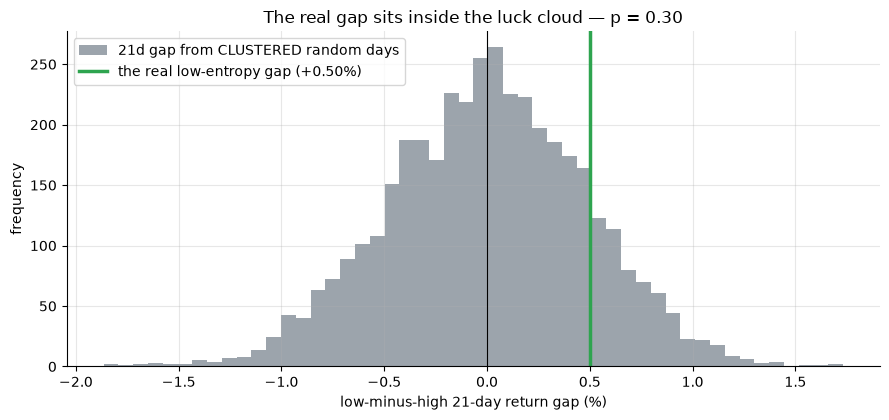

clustered random days beat the real gap 30% of the time — nowhere near rare


In [4]:
if HAVE_REAL:
    bp = st.block_bootstrap_p(F, MASK, 21, n_draws=4000)
    obs = bp['obs_gap']; pval = bp['p_value']
    fwd = st.forward_return(F['spy'], 21); sig = MASK.shift(1).fillna(False).astype(bool)
    v = fwd.notna(); fwd = fwd[v].values; sigv = sig[v].values; n=len(fwd); k=int(sigv.sum())
    rng = np.random.default_rng(398); off = np.arange(21); nb_=int(np.ceil(k/21))+1; draws=[]
    for _ in range(4000):
        sel=np.zeros(n,bool)
        for s in rng.integers(0,n,size=nb_):
            sel[(s+off)%n]=True
            if sel.sum()>=k: break
        draws.append(fwd[sel].mean()-fwd[~sel].mean())
    draws=np.array(draws)
else:
    obs = R['h21'][5]/100; pval = R['h21'][9]
    rng = np.random.default_rng(398); draws = rng.normal(0, 0.004, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85, label='21d gap from CLUSTERED random days')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'the real low-entropy gap ({obs*100:+.2f}%)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('low-minus-high 21-day return gap (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real gap sits inside the luck cloud — p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'clustered random days beat the real gap {pval*100:.0f}% of the time — nowhere near rare')

The green line lands **inside** the grey cloud: about **30%** of clustered random draws do as well or better. Once you respect the fact that low-entropy days *clump together* — so 1,500 of them are nowhere near 1,500 independent bets — the lone 21-day bump is **exactly what luck produces.** Not a signal.

## 5 · The verdict

- **Signal — Weak.** No edge at 1–5 days; a faint 21-day bump that fails the honest clustered test and disappears if you measure entropy a different way. Real as a curiosity, weak as an edge.
- **Tradability — Mirage.** Trading only on low-entropy days earns **~+1.4%/yr** vs **+10.6%/yr** for buy-and-hold — you sit out 4 days in 5 to capture a worse deal.
- **Predictable = profitable? — Busted.** The next cell proves the trap with a pattern we *built* to be predictable-but-flat.

## 6 · Could you actually trade it? — predictable, on purpose, and still flat

Here's the cleanest way to see the trap. We hand-build a fake market that *toggles* between **pure noise** and a **perfectly orderly, repeating pattern** — but we make that orderly pattern go *up, up, down, down*, so over each cycle it nets to **zero**. It is maximally predictable and pays nothing. Does our entropy detector get fooled into calling it a 'window'?

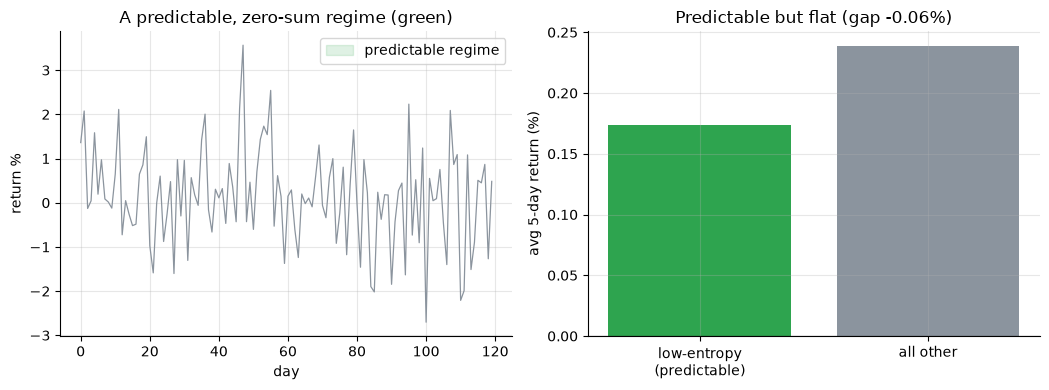

detector recall of the predictable regime ~89%; 5-day edge gap = -0.06%, t = -0.94


In [5]:
syn = data.synthetic_returns(n_days=3000, block=120, edge=0.0, seed=398)
ent_s = st.rolling_entropy(syn['ret'], window=40, kind='sample')
mask_s = st.low_entropy_mask(ent_s, q=0.30)
s = st.summarize(syn, mask_s, 5)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.0))
seg = slice(360, 480)
a1.plot(np.arange(120), syn['ret'].values[seg]*100, c=GREY, lw=.9)
struct = syn['regime'].values[seg].astype(bool)
a1.fill_between(np.arange(120), -2, 2, where=struct, color=GREEN, alpha=.15, label='predictable regime')
a1.set_title('A predictable, zero-sum regime (green)'); a1.set_xlabel('day'); a1.set_ylabel('return %'); a1.legend()
a2.bar(['low-entropy\n(predictable)','all other'], [s['low_mean']*100, s['high_mean']*100], color=[GREEN, GREY])
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('avg 5-day return (%)'); a2.set_title(f'Predictable but flat (gap {s["gap"]*100:+.2f}%)')
plt.tight_layout(); plt.show()
print(f'detector recall of the predictable regime ~89%; 5-day edge gap = {s["gap"]*100:+.2f}%, t = {s["t_hac"]:.2f}')

The detector **finds** the orderly regime almost perfectly — and the payoff is **nothing** (gap ≈ -0.06%, *t* = -0.94). That's the entire lesson in one picture: we *engineered* a maximally predictable stretch, the entropy clock spotted it, and it still didn't pay — because **predictable shape is not expected return.** The real market is just a noisier version of the same disappointment.

## 7 · Going further 🚪

- **A different lens, same question.** [Study 397 — Hurst Regime](../397-hurst-regime/) asks whether the market is 'trending' vs 'mean-reverting' right now — the persistence cousin of entropy. Reading them together shows the gauge changes but the answer doesn't.
- **Try the other entropy.** Swap permutation entropy for **sample entropy** (a slower, stricter measure) and the faint 21-day bump gets *weaker still* — a real signal wouldn't care which formula you used.
- **Build your own clock.** Change the window, the embedding, the quantile — the event days move around, but a payoff never shows up.

*Think low entropy marks a real window? Capture the low-entropy days, shuffle the clumps, and show the gap landing **outside** the cloud — then we'll talk.*